# 1. IMPORT LIBRARIES

In [1]:
import os
import re
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

import optuna
from optuna.samplers import TPESampler

import xgboost as xgb
from xgboost import XGBClassifier

from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# 2. CONFIG & LOAD DATA

In [2]:
INPUT_DIR = Path("/kaggle/input/competitions/playground-series-s6e5")

train_path = INPUT_DIR / "train.csv"
test_path = INPUT_DIR / "test.csv"
sample_path = INPUT_DIR / "sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

TARGET = "PitNextLap"
ID_COL = "id"

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (439140, 16)
Test shape : (188165, 15)
Sample submission shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


# 3. BASIC COLUMN CLEANING

In [3]:
def clean_column_name(col: str) -> str:
    col = col.strip()
    col = re.sub(r"[^0-9a-zA-Z_]+", "_", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col

original_columns = train.columns.tolist()

train.columns = [clean_column_name(c) for c in train.columns]
test.columns = [clean_column_name(c) for c in test.columns]
sample_submission.columns = [clean_column_name(c) for c in sample_submission.columns]

TARGET = clean_column_name(TARGET)
ID_COL = clean_column_name(ID_COL)

print("Original columns:")
print(original_columns)

print("\nCleaned train columns:")
print(train.columns.tolist())

Original columns:
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']

Cleaned train columns:
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


# 4.1 GENERAL OVERVIEW

In [4]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nTrain info:")
display(train.info())

print("\nMissing values - Train:")
display(
    train.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_ratio=lambda x: x["missing_count"] / len(train))
    .sort_values("missing_count", ascending=False)
)

print("\nMissing values - Test:")
display(
    test.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_ratio=lambda x: x["missing_count"] / len(test))
    .sort_values("missing_count", ascending=False)
)

print("\nDuplicated rows in train:", train.duplicated().sum())
print("Duplicated ids in train:", train[ID_COL].duplicated().sum())
print("Duplicated ids in test :", test[ID_COL].duplicated().sum())

Train shape: (439140, 16)
Test shape : (188165, 15)

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime_s               439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgr

None


Missing values - Train:


,missing_count,missing_ratio
id,0,0.0
Driver,0,0.0
Compound,0,0.0
Race,0,0.0
Year,0,0.0
PitStop,0,0.0
LapNumber,0,0.0
Stint,0,0.0
TyreLife,0,0.0
Position,0,0.0



Missing values - Test:


,missing_count,missing_ratio
id,0,0.0
Driver,0,0.0
Compound,0,0.0
Race,0,0.0
Year,0,0.0
PitStop,0,0.0
LapNumber,0,0.0
Stint,0,0.0
TyreLife,0,0.0
Position,0,0.0



Duplicated rows in train: 0
Duplicated ids in train: 0
Duplicated ids in test : 0


# 4.2 TARGET DISTRIBUTION

,count,ratio
PitNextLap,,
0.0,351759,0.801018
1.0,87381,0.198982


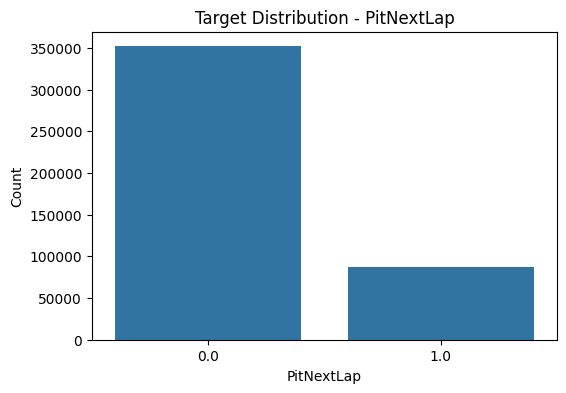

Positive class ratio: 0.19898210137996994


In [5]:
target_counts = train[TARGET].value_counts().sort_index()
target_ratio = train[TARGET].value_counts(normalize=True).sort_index()

display(pd.DataFrame({
    "count": target_counts,
    "ratio": target_ratio
}))

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=TARGET)
plt.title("Target Distribution - PitNextLap")
plt.xlabel("PitNextLap")
plt.ylabel("Count")
plt.show()

print("Positive class ratio:", train[TARGET].mean())

# 4.3 NUMERIC & CATEGORICAL COLUMNS

In [6]:
feature_cols_raw = [c for c in train.columns if c not in [ID_COL, TARGET]]

cat_cols_raw = train[feature_cols_raw].select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_raw = train[feature_cols_raw].select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols_raw)
print("Numeric columns:", num_cols_raw)

print("\nCategorical cardinality:")
display(
    train[cat_cols_raw]
    .nunique()
    .to_frame("n_unique")
    .sort_values("n_unique", ascending=False)
)

print("\nNumeric describe:")
display(train[num_cols_raw].describe().T)

Categorical columns: ['Driver', 'Compound', 'Race']
Numeric columns: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']

Categorical cardinality:


,n_unique
Driver,887
Race,26
Compound,5



Numeric describe:


,count,mean,std,min,25%,50%,75%,max
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime_s,439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026
RaceProgress,439140.0,0.337661,0.253277,0.012821,0.12987,0.269231,0.513158,1.000


# 4.4 TARGET RATE BY CATEGORICAL FEATURES

,count,mean
Driver,,
VER,1484,0.356469
NOR,1563,0.283429
WEB,1576,0.256345
KVY,1482,0.248313
BUT,1655,0.245317
TRU,1613,0.243645
RAI,1669,0.242660
BIA,1539,0.235867
KOV,1607,0.235843


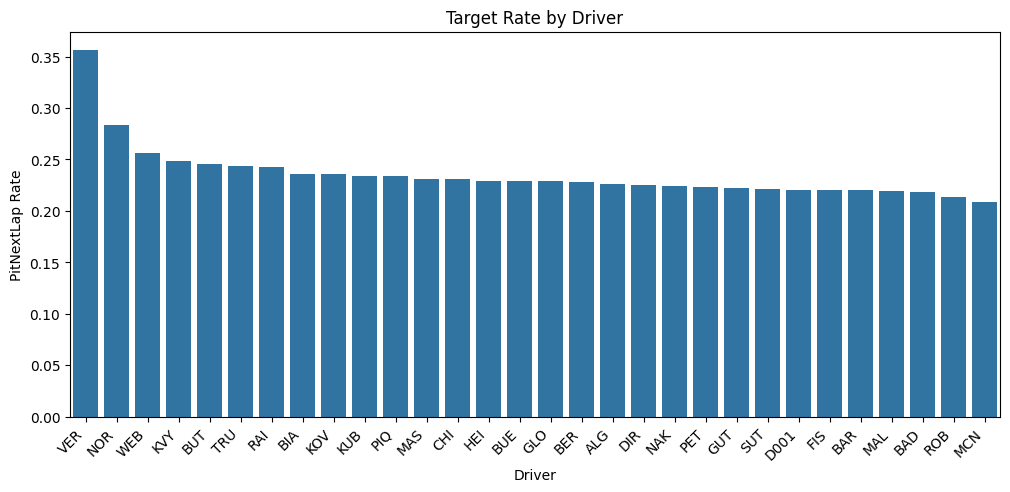

,count,mean
Compound,,
HARD,170518,0.327537
SOFT,38744,0.193475
INTERMEDIATE,17382,0.152284
MEDIUM,211141,0.101131
WET,1355,0.025092


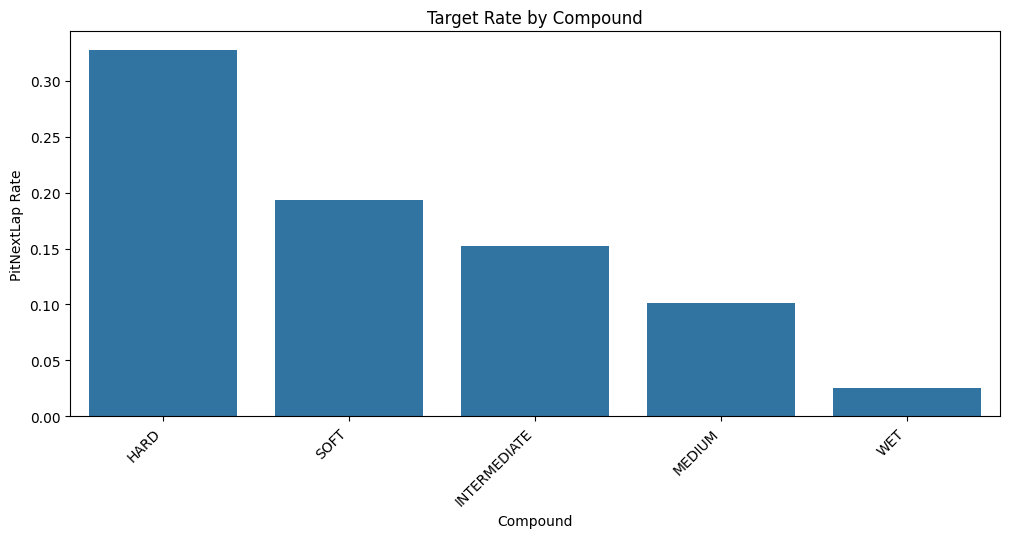

,count,mean
Race,,
Chinese Grand Prix,7311,0.388593
Monaco Grand Prix,21539,0.357398
Spanish Grand Prix,20483,0.319973
Bahrain Grand Prix,19535,0.287535
Belgian Grand Prix,9002,0.280382
Emilia Romagna Grand Prix,15483,0.272557
French Grand Prix,3185,0.257457
São Paulo Grand Prix,11497,0.253718
Hungarian Grand Prix,22481,0.239269


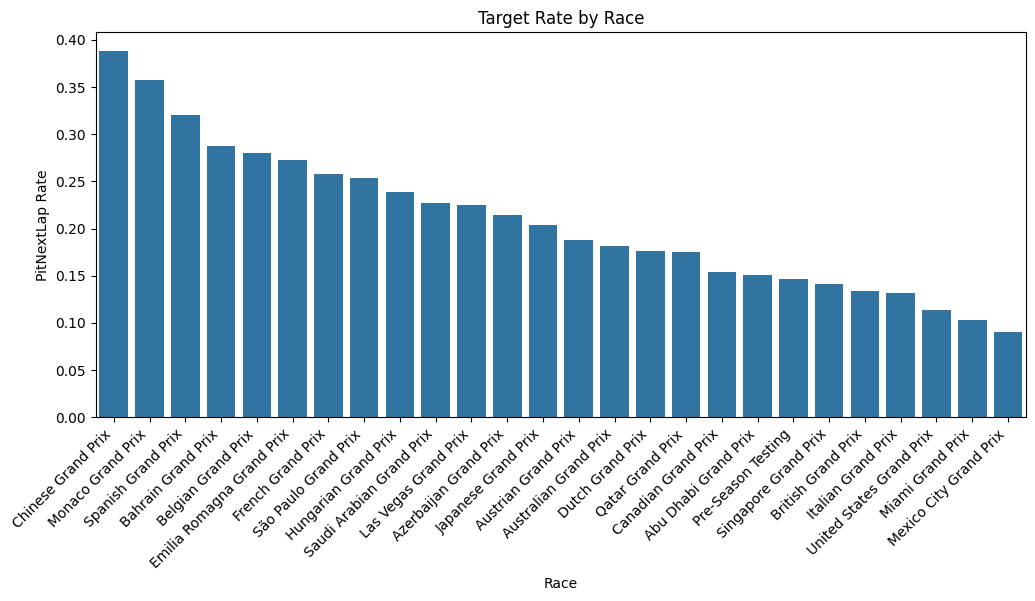

In [7]:
def plot_target_rate_by_category(df, col, target=TARGET, top_n=30):
    tmp = (
        df.groupby(col, observed=True)[target]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
        .head(top_n)
        .sort_values("mean", ascending=False)
    )
    
    display(tmp)
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=tmp.reset_index(), x=col, y="mean")
    plt.title(f"Target Rate by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("PitNextLap Rate")
    plt.show()

for col in cat_cols_raw:
    plot_target_rate_by_category(train, col)

# 4.5 TARGET RATE BY NUMERIC BINS

,LapNumber_bin,count,mean
0,"(0.999, 2.0]",26604,0.047775
1,"(2.0, 4.0]",27629,0.059865
2,"(4.0, 5.0]",12954,0.063687
3,"(5.0, 7.0]",26507,0.066435
4,"(7.0, 9.0]",21872,0.068307
5,"(9.0, 11.0]",25663,0.100612
6,"(11.0, 12.0]",13641,0.115827
7,"(12.0, 14.0]",23719,0.125258
8,"(14.0, 17.0]",27341,0.142643
9,"(17.0, 19.0]",17872,0.178771


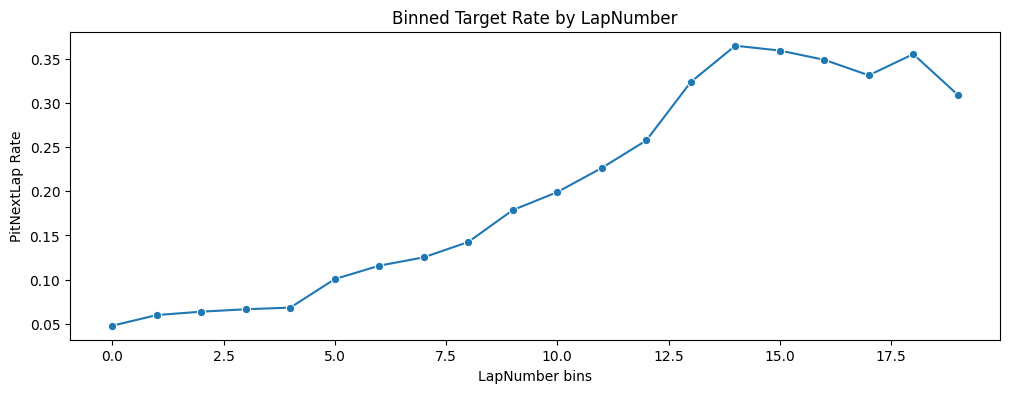

,TyreLife_bin,count,mean
0,"(0.999, 2.0]",33379,0.016927
1,"(2.0, 3.0]",18614,0.046363
2,"(3.0, 4.0]",20348,0.078435
3,"(4.0, 5.0]",18297,0.087391
4,"(5.0, 6.0]",20663,0.102018
5,"(6.0, 8.0]",36694,0.132147
6,"(8.0, 9.0]",17006,0.147477
7,"(9.0, 10.0]",18180,0.160836
8,"(10.0, 11.0]",18250,0.173260
9,"(11.0, 12.0]",19945,0.177488


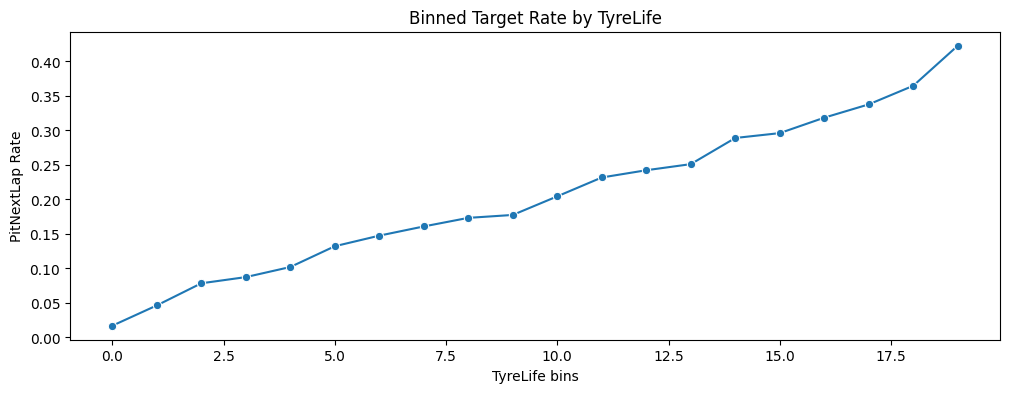

,RaceProgress_bin,count,mean
0,"(0.011800000000000001, 0.0278]",23238,0.052285
1,"(0.0278, 0.0526]",21477,0.058807
2,"(0.0526, 0.0769]",21418,0.064992
3,"(0.0769, 0.1]",22116,0.072391
4,"(0.1, 0.13]",22152,0.076968
5,"(0.13, 0.154]",22637,0.110748
6,"(0.154, 0.179]",21268,0.111435
7,"(0.179, 0.208]",21402,0.136903
8,"(0.208, 0.237]",22214,0.164131
9,"(0.237, 0.269]",22676,0.173223


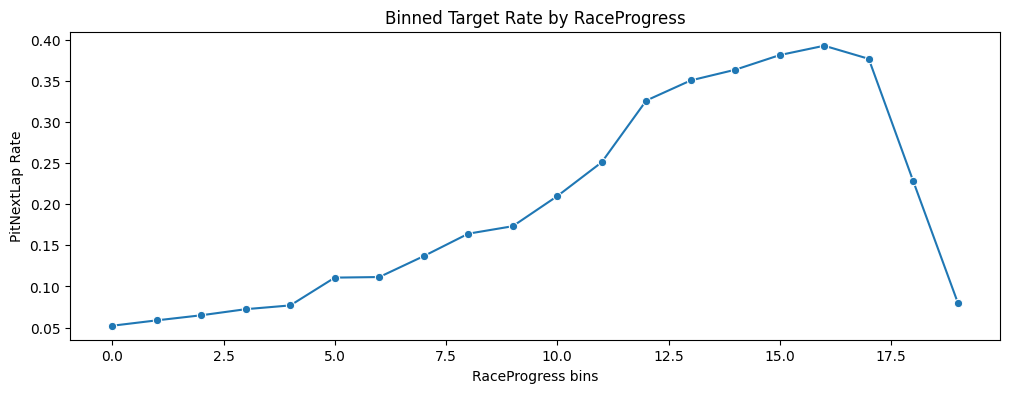

,Position_bin,count,mean
0,"(0.999, 2.0]",45268,0.173809
1,"(2.0, 3.0]",24285,0.192670
2,"(3.0, 4.0]",25267,0.178533
3,"(4.0, 5.0]",24398,0.192803
4,"(5.0, 6.0]",24845,0.190179
5,"(6.0, 7.0]",24690,0.195140
6,"(7.0, 8.0]",24777,0.207249
7,"(8.0, 9.0]",24416,0.206504
8,"(9.0, 10.0]",24700,0.195466
9,"(10.0, 11.0]",25031,0.203787


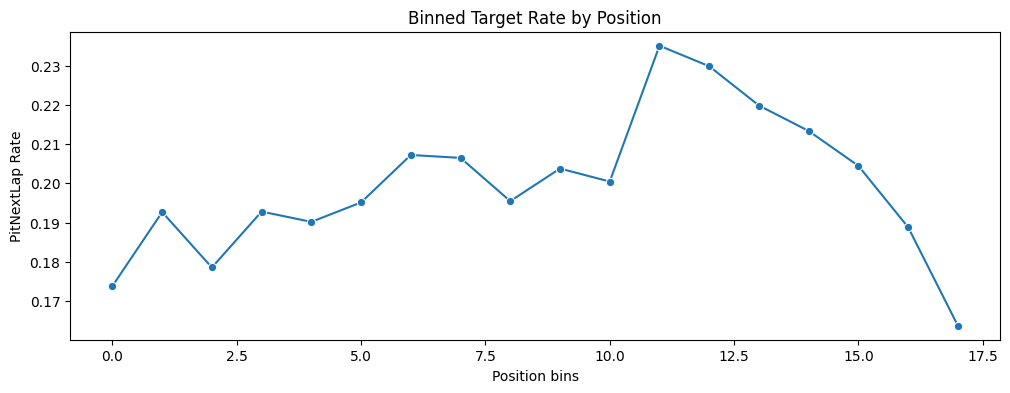

,LapTime_s_bin,count,mean
0,"(67.693, 75.053]",21963,0.211219
1,"(75.053, 77.052]",21951,0.209057
2,"(77.052, 78.859]",21974,0.193683
3,"(78.859, 81.025]",21953,0.324284
4,"(81.025, 82.621]",21948,0.327684
5,"(82.621, 83.766]",21962,0.224934
6,"(83.766, 84.832]",21993,0.179375
7,"(84.832, 85.942]",21928,0.176304
8,"(85.942, 87.858]",21961,0.147261
9,"(87.858, 90.521]",21940,0.191158


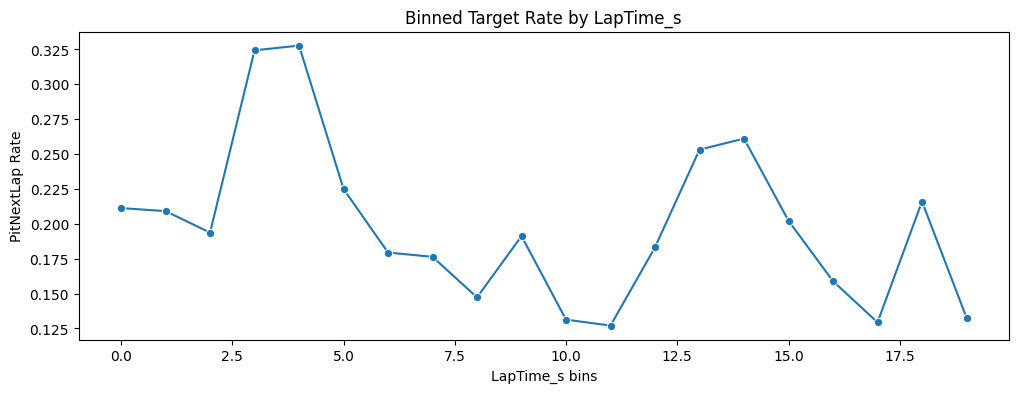

,LapTime_Delta_bin,count,mean
0,"(-2403.896, -24.819]",21970,0.227902
1,"(-24.819, -17.433]",21946,0.265151
2,"(-17.433, -13.928]",21969,0.307615
3,"(-13.928, -10.858]",21982,0.247930
4,"(-10.858, -8.884]",21923,0.285043
5,"(-8.884, -6.904]",21952,0.270499
6,"(-6.904, -4.871]",21982,0.301656
7,"(-4.871, -2.828]",21955,0.320064
8,"(-2.828, -0.933]",21975,0.309124
9,"(-0.933, -0.295]",21955,0.132453


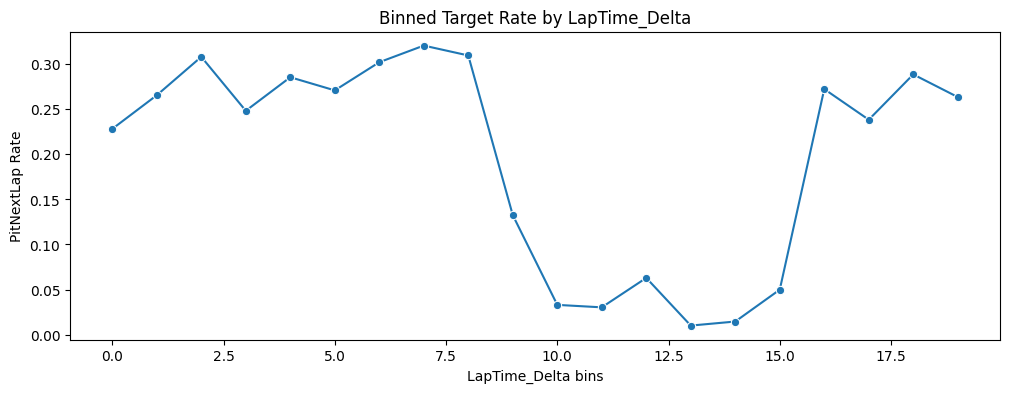

,Cumulative_Degradation_bin,count,mean
0,"(-274.565, -104.789]",21957,0.472742
1,"(-104.789, -75.748]",21958,0.184170
2,"(-75.748, -60.418]",21956,0.188240
3,"(-60.418, -52.838]",21958,0.285818
4,"(-52.838, -46.566]",21956,0.245081
5,"(-46.566, -39.973]",21975,0.259659
6,"(-39.973, -34.924]",21948,0.281073
7,"(-34.924, -29.583]",21948,0.304356
8,"(-29.583, -24.015]",21960,0.255692
9,"(-24.015, -20.994]",21978,0.151060


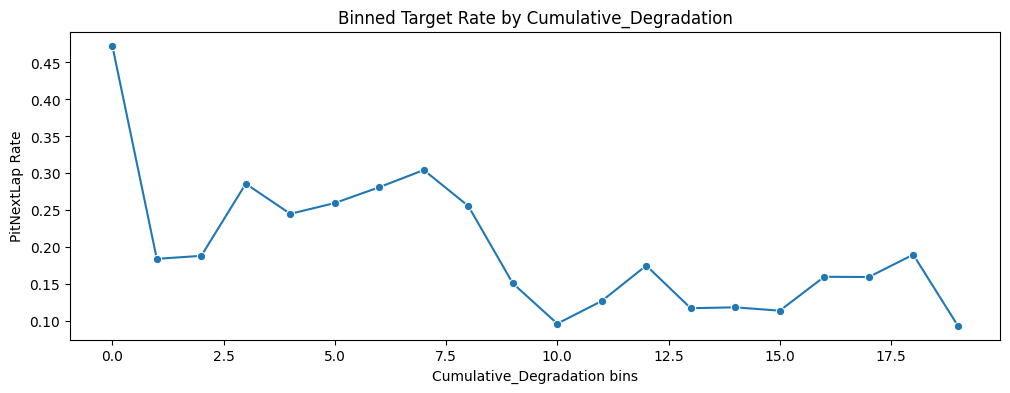

,Position_Change_bin,count,mean
0,"(-18.001, -7.0]",25709,0.210315
1,"(-7.0, -5.0]",20966,0.286559
2,"(-5.0, -3.0]",37123,0.270264
3,"(-3.0, -2.0]",25475,0.290991
4,"(-2.0, -1.0]",32075,0.245362
5,"(-1.0, 0.0]",137668,0.057486
6,"(0.0, 1.0]",41603,0.168930
7,"(1.0, 2.0]",28787,0.266718
8,"(2.0, 3.0]",20697,0.315215
9,"(3.0, 4.0]",17250,0.309623


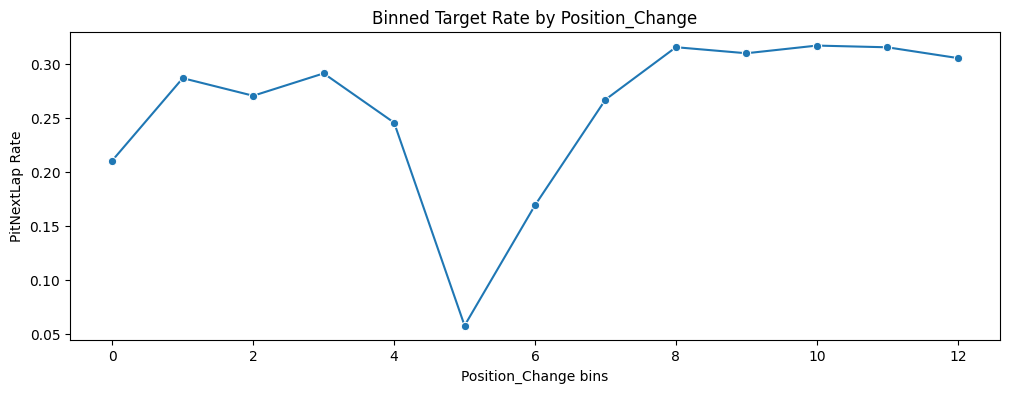

,Stint_bin,count,mean
0,"(0.999, 2.0]",345824,0.183909
1,"(2.0, 3.0]",69238,0.293105
2,"(3.0, 4.0]",18903,0.171666
3,"(4.0, 8.0]",5175,0.046763


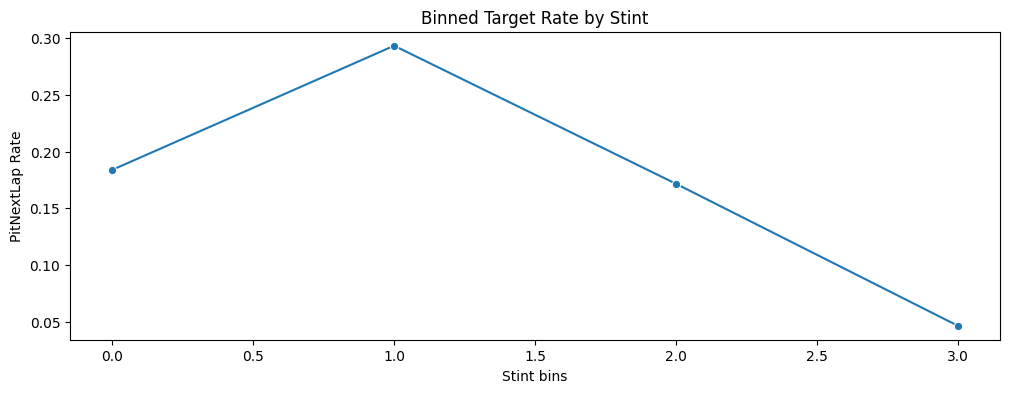

In [8]:
important_numeric = [
    "LapNumber",
    "TyreLife",
    "RaceProgress",
    "Position",
    "LapTime_s",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "Position_Change",
    "Stint"
]

important_numeric = [c for c in important_numeric if c in train.columns]

def plot_binned_target_rate(df, col, target=TARGET, bins=20):
    tmp = df[[col, target]].dropna().copy()
    
    try:
        tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=bins, duplicates="drop")
    except Exception:
        tmp[f"{col}_bin"] = pd.cut(tmp[col], bins=bins)
    
    stat = (
        tmp.groupby(f"{col}_bin", observed=True)[target]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    display(stat)
    
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=stat, x=stat.index, y="mean", marker="o")
    plt.title(f"Binned Target Rate by {col}")
    plt.xlabel(f"{col} bins")
    plt.ylabel("PitNextLap Rate")
    plt.show()

for col in important_numeric:
    plot_binned_target_rate(train, col)

# 4.6 NUMERIC DISTRIBUTION BY TARGET

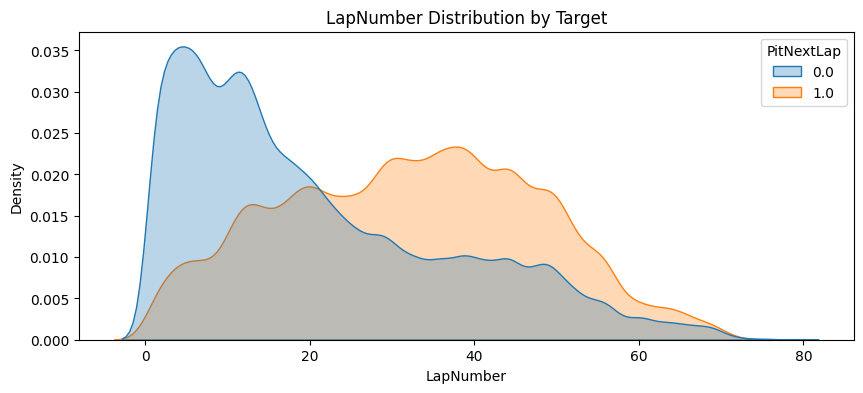

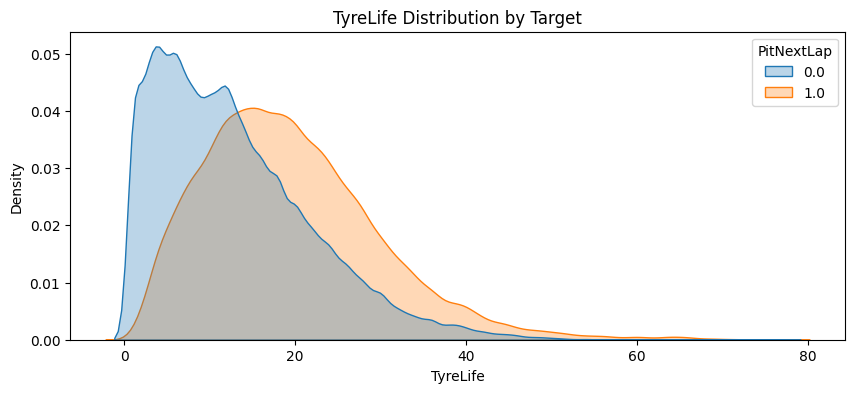

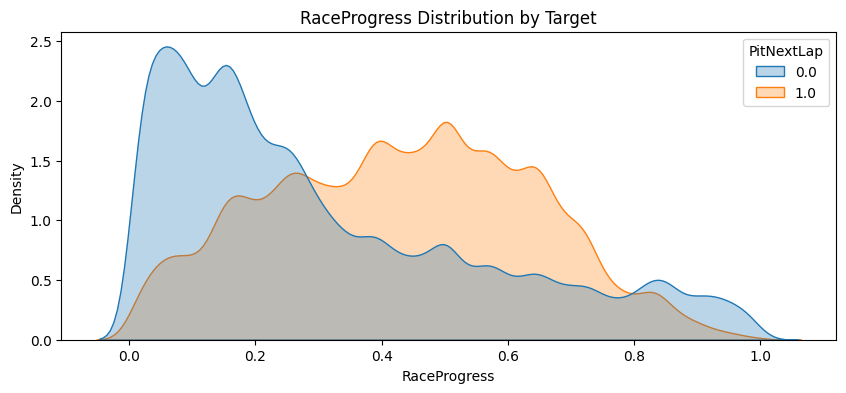

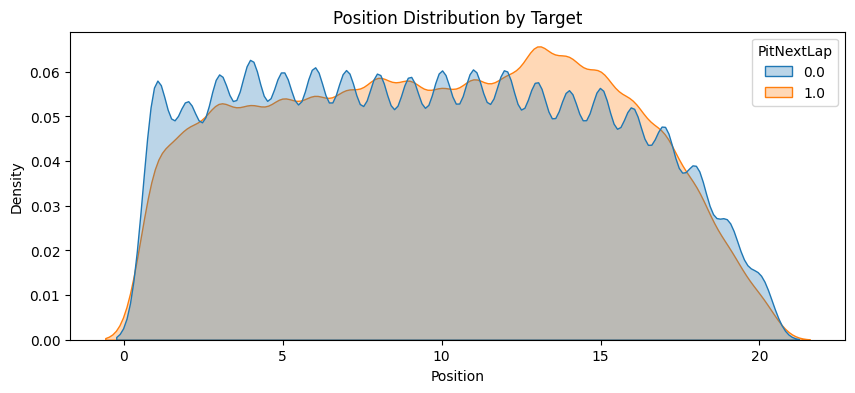

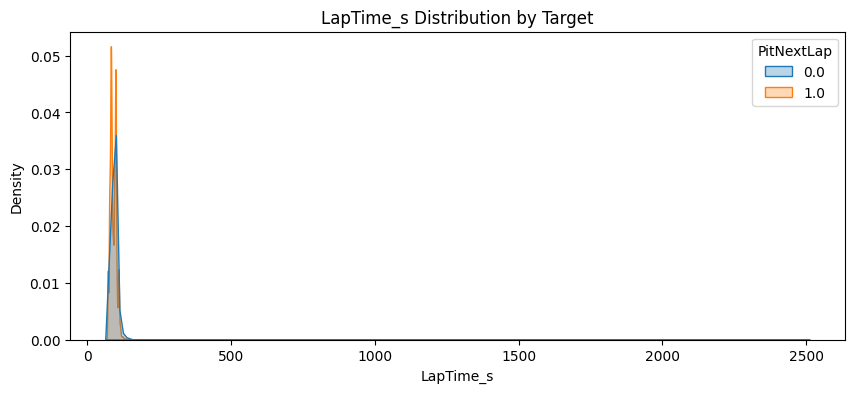

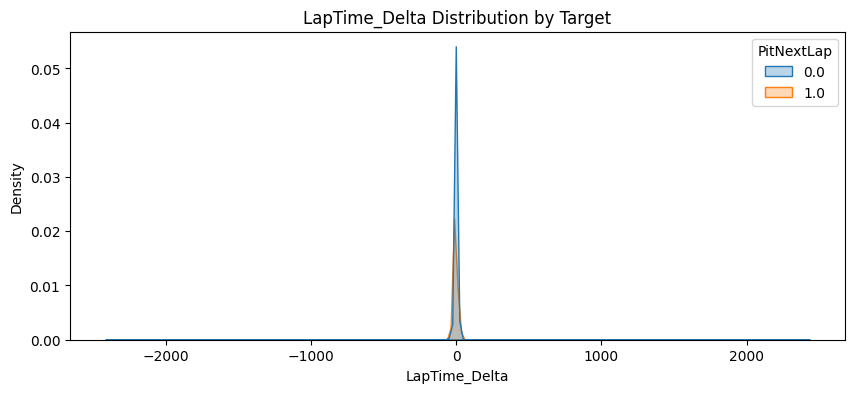

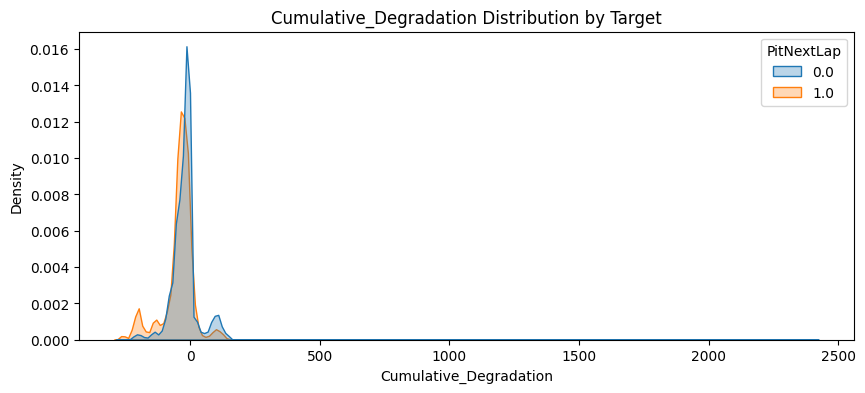

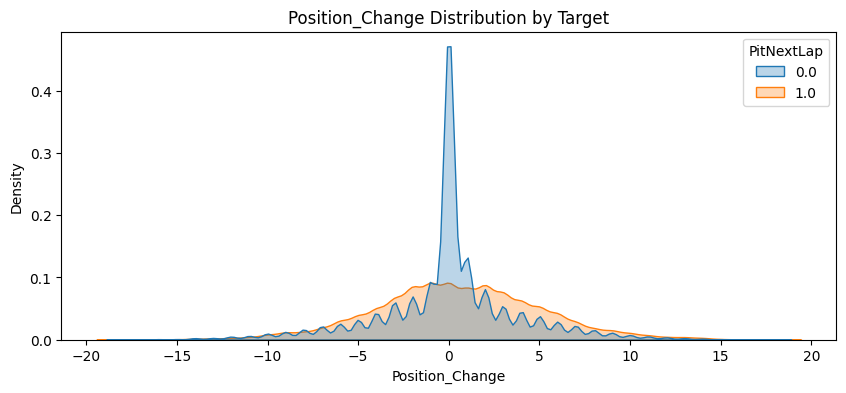

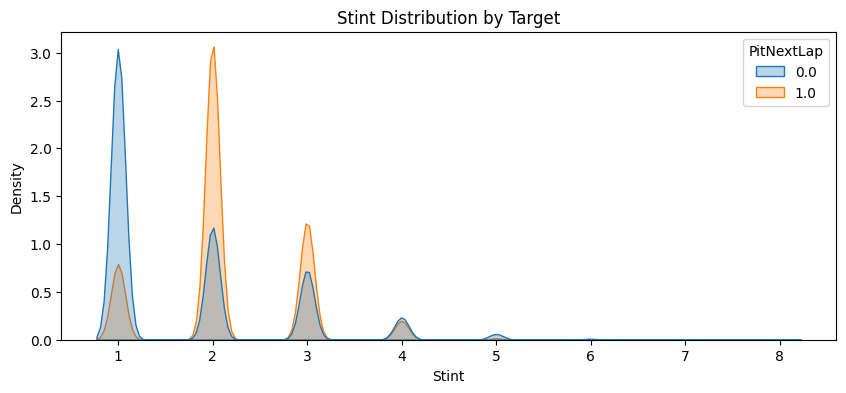

In [9]:
for col in important_numeric:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=train, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.3)
    plt.title(f"{col} Distribution by Target")
    plt.show()

# 4.7 CORRELATION HEATMAP

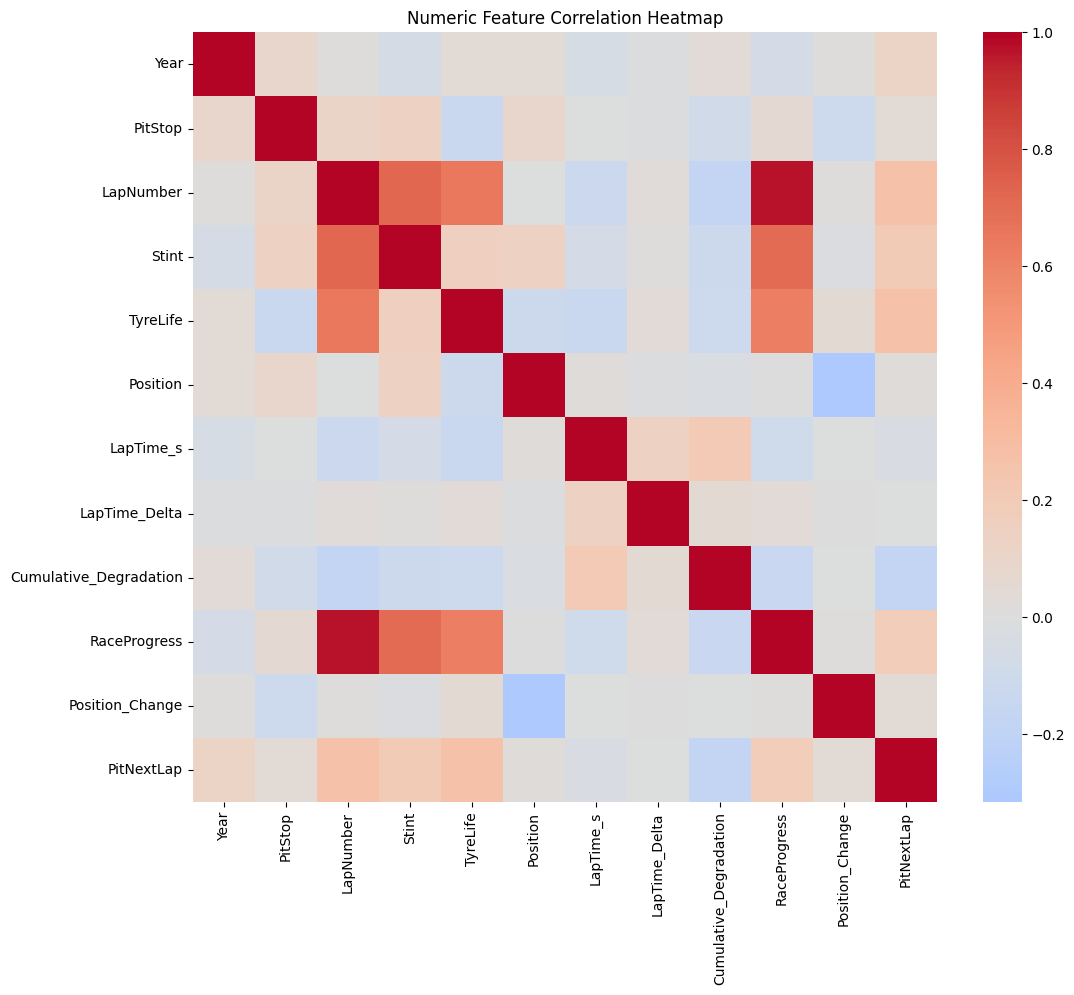

,corr_with_target
TyreLife,0.273510
LapNumber,0.267057
Stint,0.198193
RaceProgress,0.185477
Cumulative_Degradation,-0.167401
Year,0.125267
PitStop,0.048567
Position_Change,0.046230
LapTime_s,-0.034096
Position,0.021348


In [10]:
corr_cols = num_cols_raw + [TARGET]
corr_cols = [c for c in corr_cols if c in train.columns]

corr = train[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

display(
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda x: np.abs(x), ascending=False)
    .to_frame("corr_with_target")
)

# 5. FEATURE ENGINEERING

In [11]:
def safe_divide(a, b):
    return np.where(np.abs(b) > 1e-9, a / b, np.nan)


def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # ----------------------------
    # Basic numeric safety
    # ----------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    
    # ----------------------------
    # Race length estimation
    # RaceProgress ~= LapNumber / TotalLaps
    # ----------------------------
    if "LapNumber" in df.columns and "RaceProgress" in df.columns:
        df["EstimatedTotalLaps"] = safe_divide(df["LapNumber"], df["RaceProgress"])
        df["EstimatedLapsRemaining"] = df["EstimatedTotalLaps"] - df["LapNumber"]
        df["RaceProgress_x_LapNumber"] = df["RaceProgress"] * df["LapNumber"]
        
        df["IsEarlyRace"] = (df["RaceProgress"] <= 0.33).astype(int)
        df["IsMidRace"] = ((df["RaceProgress"] > 0.33) & (df["RaceProgress"] <= 0.66)).astype(int)
        df["IsLateRace"] = (df["RaceProgress"] > 0.66).astype(int)
        
        df["RacePhase"] = pd.cut(
            df["RaceProgress"],
            bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
            labels=["phase_1", "phase_2", "phase_3", "phase_4"]
        ).astype("object")
    
    # ----------------------------
    # Tyre life features
    # ----------------------------
    if "TyreLife" in df.columns:
        df["TyreLife_log1p"] = np.log1p(df["TyreLife"].clip(lower=0))
        df["TyreLife_sq"] = df["TyreLife"] ** 2
        
        if "LapNumber" in df.columns:
            df["TyreLife_to_LapNumber"] = safe_divide(df["TyreLife"], df["LapNumber"])
        
        if "EstimatedTotalLaps" in df.columns:
            df["TyreLife_to_EstTotalLaps"] = safe_divide(df["TyreLife"], df["EstimatedTotalLaps"])
        
        if "EstimatedLapsRemaining" in df.columns:
            df["TyreLife_to_LapsRemaining"] = safe_divide(df["TyreLife"], df["EstimatedLapsRemaining"] + 1)
    
    # ----------------------------
    # Degradation features
    # ----------------------------
    if "Cumulative_Degradation" in df.columns:
        df["Abs_Cumulative_Degradation"] = df["Cumulative_Degradation"].abs()
        
        if "TyreLife" in df.columns:
            df["Deg_per_TyreLife"] = safe_divide(df["Cumulative_Degradation"], df["TyreLife"] + 1)
            df["AbsDeg_per_TyreLife"] = safe_divide(df["Abs_Cumulative_Degradation"], df["TyreLife"] + 1)
        
        if "LapNumber" in df.columns:
            df["Deg_per_Lap"] = safe_divide(df["Cumulative_Degradation"], df["LapNumber"] + 1)
    
    # ----------------------------
    # Lap time features
    # ----------------------------
    if "LapTime_s" in df.columns:
        df["LapTime_log1p"] = np.log1p(df["LapTime_s"].clip(lower=0))
        
        if "LapTime_Delta" in df.columns:
            df["Abs_LapTime_Delta"] = df["LapTime_Delta"].abs()
            df["LapTime_Delta_to_LapTime"] = safe_divide(df["LapTime_Delta"], df["LapTime_s"])
        
        if "TyreLife" in df.columns:
            df["LapTime_per_TyreLife"] = safe_divide(df["LapTime_s"], df["TyreLife"] + 1)
    
    # ----------------------------
    # Position features
    # ----------------------------
    if "Position" in df.columns:
        df["IsTop3"] = (df["Position"] <= 3).astype(int)
        df["IsTop5"] = (df["Position"] <= 5).astype(int)
        df["IsPointsPosition"] = (df["Position"] <= 10).astype(int)
        df["Position_inverse"] = safe_divide(1, df["Position"])
    
    if "Position_Change" in df.columns:
        df["Abs_Position_Change"] = df["Position_Change"].abs()
        df["Gained_Position"] = (df["Position_Change"] > 0).astype(int)
        df["Lost_Position"] = (df["Position_Change"] < 0).astype(int)
    
    # ----------------------------
    # Stint / Pit features
    # ----------------------------
    if "Stint" in df.columns:
        df["Stint_sq"] = df["Stint"] ** 2
        df["IsFirstStint"] = (df["Stint"] == 1).astype(int)
        df["IsLaterStint"] = (df["Stint"] > 1).astype(int)
        
        if "LapNumber" in df.columns:
            df["LapNumber_to_Stint"] = safe_divide(df["LapNumber"], df["Stint"] + 1)
    
    if "PitStop" in df.columns:
        df["HasCurrentPitStop"] = (df["PitStop"] > 0).astype(int)
    
    # ----------------------------
    # Compound encoding by domain order
    # ----------------------------
    if "Compound" in df.columns:
        compound_map = {
            "SOFT": 3,
            "MEDIUM": 2,
            "HARD": 1,
            "INTERMEDIATE": 0,
            "WET": 0
        }
        df["Compound_Ordinal"] = df["Compound"].map(compound_map).fillna(-1).astype(float)
        
        df["IsSoft"] = (df["Compound"] == "SOFT").astype(int)
        df["IsMedium"] = (df["Compound"] == "MEDIUM").astype(int)
        df["IsHard"] = (df["Compound"] == "HARD").astype(int)
    
    # ----------------------------
    # Interaction categorical features
    # ----------------------------
    if "Compound" in df.columns and "RacePhase" in df.columns:
        df["Compound_x_RacePhase"] = df["Compound"].astype(str) + "_" + df["RacePhase"].astype(str)
    
    if "Race" in df.columns and "Compound" in df.columns:
        df["Race_x_Compound"] = df["Race"].astype(str) + "_" + df["Compound"].astype(str)
    
    if "Driver" in df.columns and "Compound" in df.columns:
        df["Driver_x_Compound"] = df["Driver"].astype(str) + "_" + df["Compound"].astype(str)
    
    if "Race" in df.columns and "Year" in df.columns:
        df["Race_x_Year"] = df["Race"].astype(str) + "_" + df["Year"].astype(str)
    
    return df

# 5.1 FREQUENCY ENCODING

In [12]:
def add_frequency_features(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    combined = pd.concat([train_df[cols], test_df[cols]], axis=0, ignore_index=True)
    
    for col in cols:
        freq = combined[col].astype(str).value_counts(normalize=True)
        train_df[f"{col}_freq"] = train_df[col].astype(str).map(freq).astype(float)
        test_df[f"{col}_freq"] = test_df[col].astype(str).map(freq).astype(float)
    
    return train_df, test_df

# 5.2 APPLY FEATURE ENGINEERING

In [13]:
train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

cat_cols_after_basic = train_fe.select_dtypes(include=["object", "category"]).columns.tolist()

# id ve target kategorik listede varsa çıkar
cat_cols_after_basic = [c for c in cat_cols_after_basic if c not in [ID_COL, TARGET]]

print("Categorical columns after basic FE:")
print(cat_cols_after_basic)

freq_cols = [
    "Driver",
    "Compound",
    "Race",
    "Year",
    "RacePhase",
    "Compound_x_RacePhase",
    "Race_x_Compound",
    "Driver_x_Compound",
    "Race_x_Year"
]

freq_cols = [c for c in freq_cols if c in train_fe.columns]

train_fe, test_fe = add_frequency_features(train_fe, test_fe, freq_cols)

print("Train FE shape:", train_fe.shape)
print("Test FE shape :", test_fe.shape)

display(train_fe.head())

Categorical columns after basic FE:
['Driver', 'Compound', 'Race', 'RacePhase', 'Compound_x_RacePhase', 'Race_x_Compound', 'Driver_x_Compound', 'Race_x_Year']
Train FE shape: (439140, 65)
Test FE shape : (188165, 64)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime_s,LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,EstimatedTotalLaps,EstimatedLapsRemaining,RaceProgress_x_LapNumber,IsEarlyRace,IsMidRace,IsLateRace,RacePhase,TyreLife_log1p,TyreLife_sq,TyreLife_to_LapNumber,TyreLife_to_EstTotalLaps,TyreLife_to_LapsRemaining,Abs_Cumulative_Degradation,Deg_per_TyreLife,AbsDeg_per_TyreLife,Deg_per_Lap,LapTime_log1p,Abs_LapTime_Delta,LapTime_Delta_to_LapTime,LapTime_per_TyreLife,IsTop3,IsTop5,IsPointsPosition,Position_inverse,Abs_Position_Change,Gained_Position,Lost_Position,Stint_sq,IsFirstStint,IsLaterStint,LapNumber_to_Stint,HasCurrentPitStop,Compound_Ordinal,IsSoft,IsMedium,IsHard,Compound_x_RacePhase,Race_x_Compound,Driver_x_Compound,Race_x_Year,Driver_freq,Compound_freq,Race_freq,Year_freq,RacePhase_freq,Compound_x_RacePhase_freq,Race_x_Compound_freq,Driver_x_Compound_freq,Race_x_Year_freq
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,70.0,20.0,35.714286,0,0,1,phase_3,3.688879,1521.0,0.780000,0.557143,1.857143,21.019,0.525475,0.525475,0.412137,4.375644,7.564,-0.096368,1.962275,0,0,1,0.125000,5.0,1,0,4,0,1,16.666667,0,1.0,0,0,1,HARD_phase_3,Canadian Grand Prix_HARD,D109_HARD,Canadian Grand Prix_2022,0.002362,0.387682,0.048638,0.188643,0.170775,0.116219,0.026906,0.000854,0.011331
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,78.0,51.0,9.346154,0,1,0,phase_2,2.079442,49.0,0.259259,0.089744,0.134615,223.207,-27.900875,27.900875,-7.971679,4.331983,32.617,-0.434343,9.386875,0,1,1,0.250000,3.0,0,1,4,0,1,9.000000,1,1.0,0,0,1,HARD_phase_2,Dutch Grand Prix_HARD,D086_HARD,Dutch Grand Prix_2025,0.002563,0.387682,0.055479,0.212048,0.270152,0.148276,0.014133,0.000941,0.014723
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,72.0,13.0,48.347222,0,0,1,phase_4,3.135494,484.0,0.372881,0.305556,1.571429,100.529,-4.370826,4.370826,-1.675483,4.275902,7.540,-0.106280,3.084565,0,0,0,0.076923,3.0,1,0,9,0,1,14.750000,0,1.0,0,0,1,HARD_phase_4,Austrian Grand Prix_HARD,ZON_HARD,Austrian Grand Prix_2022,0.003360,0.387682,0.047870,0.188643,0.084567,0.050502,0.020508,0.001361,0.010170
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,26.0,24.0,0.153846,1,0,0,phase_1,1.098612,4.0,1.000000,0.076923,0.080000,7.324,-2.441333,2.441333,-2.441333,4.557670,7.324,-0.077617,31.453667,0,0,1,0.142857,0.0,0,0,1,1,0,1.000000,0,2.0,0,1,0,MEDIUM_phase_1,Pre-Season Testing_MEDIUM,SPE_MEDIUM,Pre-Season Testing_2023,0.003319,0.481485,0.051233,0.309749,0.474506,0.332047,0.035016,0.001505,0.017798
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,72.0,46.0,9.388889,0,1,0,phase_2,1.945910,36.0,0.230769,0.083333,0.127660,14.139,-2.019857,2.019857,-0.523667,4.690228,8.965,0.083103,15.411143,1,1,1,0.500000,3.0,1,0,9,0,1,6.500000,1,1.0,0,0,1,HARD_phase_2,Azerbaijan Grand Prix_HARD,D019_HARD,Azerbaijan Grand Prix_2022,0.003244,0.387682,0.027695,0.188643,0.270152,0.148276,0.019337,0.001161,0.005823


# 5.3 PREPARE MODEL MATRIX

In [14]:
DROP_COLS = [ID_COL, TARGET]

features = [c for c in train_fe.columns if c not in DROP_COLS]

X = train_fe[features].copy()
y = train_fe[TARGET].astype(int).copy()
X_test = test_fe[features].copy()

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in features if c not in cat_cols]

print("Number of features:", len(features))
print("Number of categorical features:", len(cat_cols))
print("Number of numeric features:", len(num_cols))

print("\nCategorical features:")
print(cat_cols)

print("\nNumeric features sample:")
print(num_cols[:30])

Number of features: 63
Number of categorical features: 8
Number of numeric features: 55

Categorical features:
['Driver', 'Compound', 'Race', 'RacePhase', 'Compound_x_RacePhase', 'Race_x_Compound', 'Driver_x_Compound', 'Race_x_Year']

Numeric features sample:
['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'EstimatedTotalLaps', 'EstimatedLapsRemaining', 'RaceProgress_x_LapNumber', 'IsEarlyRace', 'IsMidRace', 'IsLateRace', 'TyreLife_log1p', 'TyreLife_sq', 'TyreLife_to_LapNumber', 'TyreLife_to_EstTotalLaps', 'TyreLife_to_LapsRemaining', 'Abs_Cumulative_Degradation', 'Deg_per_TyreLife', 'AbsDeg_per_TyreLife', 'Deg_per_Lap', 'LapTime_log1p', 'Abs_LapTime_Delta', 'LapTime_Delta_to_LapTime', 'LapTime_per_TyreLife']


# 5.4 CATEGORICAL ALIGNMENT FOR XGBOOST NATIVE CATEGORICAL

In [15]:
def align_categorical_columns(train_df, test_df, cat_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    for col in cat_cols:
        train_df[col] = train_df[col].astype("string").fillna("missing")
        test_df[col] = test_df[col].astype("string").fillna("missing")
        
        categories = pd.concat([train_df[col], test_df[col]], axis=0).unique().tolist()
        categories = sorted(categories)
        
        cat_type = pd.CategoricalDtype(categories=categories)
        train_df[col] = train_df[col].astype(cat_type)
        test_df[col] = test_df[col].astype(cat_type)
    
    return train_df, test_df

X, X_test = align_categorical_columns(X, X_test, cat_cols)

# Numeric inf temizliği
for col in num_cols:
    X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    X_test[col] = X_test[col].replace([np.inf, -np.inf], np.nan)

print(X.dtypes.value_counts())

float64     35
int64       20
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


# 6. STRATIFIED KFOLD + XGBOOST FIXED BEST PARAMS

In [16]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

positive_count = y.sum()
negative_count = len(y) - positive_count
base_scale_pos_weight = negative_count / max(positive_count, 1)

print("Positive count:", positive_count)
print("Negative count:", negative_count)
print("Base scale_pos_weight:", base_scale_pos_weight)

Positive count: 87381
Negative count: 351759
Base scale_pos_weight: 4.025577642736979


# 6.1 FIXED BEST PARAMS

In [17]:
best_params = {
    "learning_rate": 0.06855230040874244,
    "max_depth": 8,
    "min_child_weight": 79.20351204809234,
    "subsample": 0.8908049953657421,
    "colsample_bytree": 0.7834034588719464,
    "gamma": 1.7695921264486392,
    "reg_alpha": 0.7810567407631214,
    "reg_lambda": 0.25756402771244674,
    "max_bin": 166,
    "grow_policy": "depthwise",
    "scale_pos_weight": 2.0452482388533655,
}


final_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "enable_categorical": True,
    "random_state": SEED,
    "n_estimators": 8000,
    "early_stopping_rounds": 200,
    "n_jobs": -1,
    **best_params,
}

# 7. FINAL STRATIFIED KFOLD TRAINING

In [18]:
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []
fold_models = []
roc_data = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = XGBClassifier(**final_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=200
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    oof_preds[valid_idx] = valid_pred
    test_preds += test_pred / N_SPLITS

    fold_auc = roc_auc_score(y_valid, valid_pred)
    fold_scores.append(fold_auc)

    fpr, tpr, _ = roc_curve(y_valid, valid_pred)
    roc_data.append((fold, fpr, tpr, fold_auc))

    fold_models.append(model)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

    gc.collect()

overall_auc = roc_auc_score(y, oof_preds)

print("\n===================================")
print("Fold AUC scores:", fold_scores)
print("Mean Fold AUC :", np.mean(fold_scores))
print("Std Fold AUC  :", np.std(fold_scores))
print("OOF AUC       :", overall_auc)
print("===================================")


========== Fold 1 ==========
[0]	validation_0-auc:0.93500
[200]	validation_0-auc:0.95093
[400]	validation_0-auc:0.95195
[600]	validation_0-auc:0.95217
[775]	validation_0-auc:0.95210
Fold 1 AUC: 0.952200

========== Fold 2 ==========
[0]	validation_0-auc:0.93327
[200]	validation_0-auc:0.94895
[400]	validation_0-auc:0.95007
[600]	validation_0-auc:0.95017
[670]	validation_0-auc:0.95012
Fold 2 AUC: 0.950246

========== Fold 3 ==========
[0]	validation_0-auc:0.93467
[200]	validation_0-auc:0.95009
[400]	validation_0-auc:0.95102
[600]	validation_0-auc:0.95105
[689]	validation_0-auc:0.95099
Fold 3 AUC: 0.951137

========== Fold 4 ==========
[0]	validation_0-auc:0.93332
[200]	validation_0-auc:0.94861
[400]	validation_0-auc:0.94971
[600]	validation_0-auc:0.94997
[800]	validation_0-auc:0.94984
[813]	validation_0-auc:0.94986
Fold 4 AUC: 0.949975

========== Fold 5 ==========
[0]	validation_0-auc:0.93388
[200]	validation_0-auc:0.95037
[400]	validation_0-auc:0.95150
[600]	validation_0-auc:0.95169
[

# 8. CATBOOST + STRATIFIED KFOLD

In [19]:
X_cb = X.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    all_values = pd.concat(
        [
            X_cb[col].astype(str).fillna("missing"),
            X_test_cb[col].astype(str).fillna("missing")
        ],
        axis=0
    )

    codes, uniques = pd.factorize(all_values)

    X_cb[col] = codes[:len(X_cb)]
    X_test_cb[col] = codes[len(X_cb):]

X_cb = X_cb.replace([np.inf, -np.inf], np.nan)
X_test_cb = X_test_cb.replace([np.inf, -np.inf], np.nan)

X_cb = X_cb.astype("float32")
X_test_cb = X_test_cb.astype("float32")

print("CatBoost train shape:", X_cb.shape)
print("CatBoost test shape :", X_test_cb.shape)
print("CatBoost dtypes:")
print(X_cb.dtypes.value_counts())

CatBoost train shape: (439140, 63)
CatBoost test shape : (188165, 63)
CatBoost dtypes:
float32    63
Name: count, dtype: int64


# 9. FINAL CATBOOST STRATIFIED KFOLD TRAINING

In [20]:

best_cat_params = {'learning_rate': 0.0643657479075778,
 'depth': 7,
 'l2_leaf_reg': 25.048257256503327,
 'random_strength': 4.949097955008386,
 'border_count': 254,
 'scale_pos_weight': 1.6289424899892675}

final_cat_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": SEED,

    "task_type": "GPU",

    "iterations": 4000,
    "early_stopping_rounds": 200,
    "verbose": 200,
    "allow_writing_files": False,

    **best_cat_params,
}

cat_oof_preds = np.zeros(len(X_cb))
cat_test_preds = np.zeros(len(X_test_cb))

cat_fold_scores = []
cat_fold_models = []
cat_roc_data = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cb, y), start=1):
    print(f"\n========== CatBoost Fold {fold} ==========")

    X_train, X_valid = X_cb.iloc[train_idx], X_cb.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostClassifier(**final_cat_params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    test_pred = model.predict_proba(X_test_cb)[:, 1]

    cat_oof_preds[valid_idx] = valid_pred
    cat_test_preds += test_pred / N_SPLITS

    fold_auc = roc_auc_score(y_valid, valid_pred)
    cat_fold_scores.append(fold_auc)

    fpr, tpr, _ = roc_curve(y_valid, valid_pred)
    cat_roc_data.append((fold, fpr, tpr, fold_auc))

    cat_fold_models.append(model)

    print(f"CatBoost Fold {fold} AUC: {fold_auc:.6f}")

    gc.collect()

cat_overall_auc = roc_auc_score(y, cat_oof_preds)

print("\n===================================")
print("CatBoost Fold AUC scores:", cat_fold_scores)
print("CatBoost Mean Fold AUC :", np.mean(cat_fold_scores))
print("CatBoost Std Fold AUC  :", np.std(cat_fold_scores))
print("CatBoost OOF AUC       :", cat_overall_auc)
print("===================================")


========== CatBoost Fold 1 ==========


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9123960	best: 0.9123960 (0)	total: 280ms	remaining: 18m 39s
200:	test: 0.9441275	best: 0.9441275 (200)	total: 3.19s	remaining: 1m
400:	test: 0.9481785	best: 0.9481785 (400)	total: 5.97s	remaining: 53.6s
600:	test: 0.9494995	best: 0.9494995 (600)	total: 8.76s	remaining: 49.5s
800:	test: 0.9501644	best: 0.9501644 (800)	total: 11.6s	remaining: 46.2s
1000:	test: 0.9506268	best: 0.9506268 (1000)	total: 14.3s	remaining: 42.9s
1200:	test: 0.9509667	best: 0.9509667 (1200)	total: 17s	remaining: 39.7s
1400:	test: 0.9511889	best: 0.9511901 (1395)	total: 19.8s	remaining: 36.7s
1600:	test: 0.9513828	best: 0.9513847 (1592)	total: 22.5s	remaining: 33.8s
1800:	test: 0.9514984	best: 0.9515039 (1792)	total: 25.3s	remaining: 30.9s
2000:	test: 0.9516234	best: 0.9516273 (1997)	total: 28.1s	remaining: 28.1s
2200:	test: 0.9517145	best: 0.9517186 (2195)	total: 30.7s	remaining: 25.1s
2400:	test: 0.9518020	best: 0.9518042 (2398)	total: 33.4s	remaining: 22.3s
2600:	test: 0.9518582	best: 0.9518582 (259

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9095224	best: 0.9095224 (0)	total: 13.9ms	remaining: 55.5s
200:	test: 0.9425986	best: 0.9425986 (200)	total: 2.57s	remaining: 48.6s
400:	test: 0.9464970	best: 0.9464970 (400)	total: 5.39s	remaining: 48.4s
600:	test: 0.9478326	best: 0.9478326 (600)	total: 8.22s	remaining: 46.5s
800:	test: 0.9486579	best: 0.9486579 (800)	total: 11s	remaining: 44.1s
1000:	test: 0.9490932	best: 0.9490932 (1000)	total: 13.8s	remaining: 41.2s
1200:	test: 0.9494562	best: 0.9494570 (1199)	total: 16.3s	remaining: 37.9s
1400:	test: 0.9496738	best: 0.9496738 (1400)	total: 18.7s	remaining: 34.8s
1600:	test: 0.9498859	best: 0.9498859 (1600)	total: 21.2s	remaining: 31.8s
1800:	test: 0.9499917	best: 0.9499972 (1780)	total: 23.8s	remaining: 29s
2000:	test: 0.9500352	best: 0.9500368 (1993)	total: 26.7s	remaining: 26.6s
2200:	test: 0.9500614	best: 0.9500759 (2167)	total: 29.5s	remaining: 24.1s
2400:	test: 0.9501218	best: 0.9501235 (2394)	total: 32.3s	remaining: 21.5s
2600:	test: 0.9501526	best: 0.9501621 (248

...

0:	test: 0.9112717	best: 0.9112717 (0)	total: 17.1ms	remaining: 1m 8s
200:	test: 0.9439702	best: 0.9439702 (200)	total: 2.8s	remaining: 53s
400:	test: 0.9476880	best: 0.9476880 (400)	total: 5.59s	remaining: 50.2s
600:	test: 0.9489415	best: 0.9489415 (600)	total: 8.35s	remaining: 47.2s
800:	test: 0.9495514	best: 0.9495514 (800)	total: 11s	remaining: 43.9s
1000:	test: 0.9499619	best: 0.9499648 (999)	total: 13.8s	remaining: 41.5s
1200:	test: 0.9503028	best: 0.9503043 (1199)	total: 16.6s	remaining: 38.7s
1400:	test: 0.9505200	best: 0.9505200 (1399)	total: 19.4s	remaining: 35.9s
1600:	test: 0.9506756	best: 0.9506774 (1597)	total: 22.3s	remaining: 33.4s
1800:	test: 0.9507906	best: 0.9507933 (1798)	total: 25.1s	remaining: 30.6s
2000:	test: 0.9508706	best: 0.9508752 (1983)	total: 27.8s	remaining: 27.8s
2200:	test: 0.9509330	best: 0.9509338 (2199)	total: 30.7s	remaining: 25.1s
2400:	test: 0.9509524	best: 0.9509686 (2334)	total: 33.5s	remaining: 22.3s
2600:	test: 0.9509570	best: 0.9509826 (2538)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9104655	best: 0.9104655 (0)	total: 16.4ms	remaining: 1m 5s
200:	test: 0.9423949	best: 0.9423949 (200)	total: 2.8s	remaining: 52.9s
400:	test: 0.9463938	best: 0.9463938 (400)	total: 5.59s	remaining: 50.1s
600:	test: 0.9477078	best: 0.9477078 (600)	total: 8.36s	remaining: 47.3s
800:	test: 0.9484475	best: 0.9484479 (799)	total: 11.1s	remaining: 44.5s
1000:	test: 0.9489152	best: 0.9489155 (999)	total: 13.9s	remaining: 41.6s
1200:	test: 0.9493022	best: 0.9493023 (1199)	total: 16.6s	remaining: 38.8s
1400:	test: 0.9495426	best: 0.9495435 (1399)	total: 19.4s	remaining: 35.9s
1600:	test: 0.9497050	best: 0.9497050 (1600)	total: 22s	remaining: 33s
1800:	test: 0.9498755	best: 0.9498768 (1799)	total: 24.6s	remaining: 30.1s
2000:	test: 0.9499804	best: 0.9499851 (1966)	total: 27.2s	remaining: 27.2s
2200:	test: 0.9500380	best: 0.9500391 (2192)	total: 29.9s	remaining: 24.5s
2400:	test: 0.9500819	best: 0.9500906 (2383)	total: 32.7s	remaining: 21.8s
2600:	test: 0.9501438	best: 0.9501438 (2600)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9104171	best: 0.9104171 (0)	total: 16.1ms	remaining: 1m 4s
200:	test: 0.9432220	best: 0.9432220 (200)	total: 2.79s	remaining: 52.7s
400:	test: 0.9476680	best: 0.9476680 (400)	total: 5.48s	remaining: 49.2s
600:	test: 0.9490259	best: 0.9490266 (599)	total: 8.2s	remaining: 46.4s
800:	test: 0.9497318	best: 0.9497318 (800)	total: 10.8s	remaining: 43.3s
1000:	test: 0.9501809	best: 0.9501822 (997)	total: 13.5s	remaining: 40.4s
1200:	test: 0.9504917	best: 0.9504917 (1200)	total: 16s	remaining: 37.4s
1400:	test: 0.9507561	best: 0.9507580 (1391)	total: 18.6s	remaining: 34.6s
1600:	test: 0.9508732	best: 0.9508831 (1566)	total: 21.2s	remaining: 31.8s
1800:	test: 0.9510202	best: 0.9510202 (1800)	total: 23.9s	remaining: 29.2s
2000:	test: 0.9511289	best: 0.9511290 (1999)	total: 26.6s	remaining: 26.6s
2200:	test: 0.9512191	best: 0.9512202 (2198)	total: 29.3s	remaining: 24s
2400:	test: 0.9513036	best: 0.9513072 (2394)	total: 32.1s	remaining: 21.4s
2600:	test: 0.9513358	best: 0.9513447 (2557)

# 10. XGBOOST + CATBOOST ENSEMBLE

In [21]:
xgb_auc = roc_auc_score(y, oof_preds)
cat_auc = roc_auc_score(y, cat_oof_preds)

print("XGBoost OOF AUC :", xgb_auc)
print("CatBoost OOF AUC:", cat_auc)

ensemble_results = []

for w_xgb in np.arange(0.0, 1.01, 0.01):
    w_cat = 1.0 - w_xgb

    ens_oof = (w_xgb * oof_preds) + (w_cat * cat_oof_preds)
    ens_auc = roc_auc_score(y, ens_oof)

    ensemble_results.append({
        "w_xgb": w_xgb,
        "w_cat": w_cat,
        "auc": ens_auc
    })

ensemble_df = pd.DataFrame(ensemble_results).sort_values("auc", ascending=False)

display(ensemble_df.head(20))

best_w_xgb = ensemble_df.iloc[0]["w_xgb"]
best_w_cat = ensemble_df.iloc[0]["w_cat"]

ensemble_oof_preds = best_w_xgb * oof_preds + best_w_cat * cat_oof_preds
ensemble_test_preds = best_w_xgb * test_preds + best_w_cat * cat_test_preds

print("Best XGB weight:", best_w_xgb)
print("Best CAT weight:", best_w_cat)
print("Best Ensemble OOF AUC:", roc_auc_score(y, ensemble_oof_preds))

XGBoost OOF AUC : 0.9510422591347139
CatBoost OOF AUC: 0.9509526706994152


,w_xgb,w_cat,auc
51,0.51,0.49,0.951846
50,0.50,0.50,0.951846
52,0.52,0.48,0.951846
53,0.53,0.47,0.951845
49,0.49,0.51,0.951845
54,0.54,0.46,0.951843
48,0.48,0.52,0.951843
55,0.55,0.45,0.951841
47,0.47,0.53,0.951841
56,0.56,0.44,0.951838


Best XGB weight: 0.51
Best CAT weight: 0.49
Best Ensemble OOF AUC: 0.9518462573044827


# 11. ENSEMBLE ROC CURVE

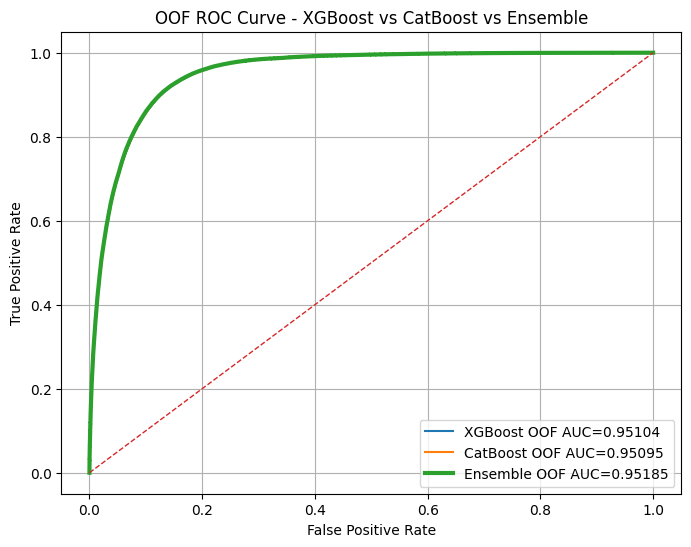

In [22]:
xgb_fpr, xgb_tpr, _ = roc_curve(y, oof_preds)
cat_fpr, cat_tpr, _ = roc_curve(y, cat_oof_preds)
ens_fpr, ens_tpr, _ = roc_curve(y, ensemble_oof_preds)

plt.figure(figsize=(8, 6))

plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost OOF AUC={xgb_auc:.5f}")
plt.plot(cat_fpr, cat_tpr, label=f"CatBoost OOF AUC={cat_auc:.5f}")
plt.plot(
    ens_fpr,
    ens_tpr,
    linewidth=3,
    label=f"Ensemble OOF AUC={roc_auc_score(y, ensemble_oof_preds):.5f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.title("OOF ROC Curve - XGBoost vs CatBoost vs Ensemble")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 12. ENSEMBLE SUBMISSION

In [23]:
submission = sample_submission.copy()
submission[TARGET] = np.clip(ensemble_test_preds, 0, 1)

display(submission.head())
display(submission[TARGET].describe())

submission.to_csv("submission_xgb_cat_ensemble.csv", index=False)

print("submission_xgb_cat_ensemble.csv saved successfully.")

,id,PitNextLap
0,439140,0.007430
1,439141,0.009671
2,439142,0.004687
3,439143,0.289306
4,439144,0.905510


count    188165.000000
mean          0.235096
std           0.329173
min           0.000160
25%           0.004739
50%           0.028821
75%           0.446365
max           0.993931
Name: PitNextLap, dtype: float64

submission_xgb_cat_ensemble.csv saved successfully.
